# 线性回归的从零开始实现
:label:`sec_linear_scratch`

在了解线性回归的关键思想之后，我们可以开始通过代码来动手实现线性回归了。
在这一节中，(**我们将从零开始实现整个方法，
包括数据流水线、模型、损失函数和小批量随机梯度下降优化器**)。
虽然现代的深度学习框架几乎可以自动化地进行所有这些工作，但从零开始实现可以确保我们真正知道自己在做什么。
同时，了解更细致的工作原理将方便我们自定义模型、自定义层或自定义损失函数。
在这一节中，我们将只使用张量和自动求导。
在之后的章节中，我们会充分利用深度学习框架的优势，介绍更简洁的实现方式。

In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

## 生成数据集

为了简单起见，我们将[**根据带有噪声的线性模型构造一个人造数据集。**]
我们的任务是使用这个有限样本的数据集来恢复这个模型的参数。
我们将使用低维数据，这样可以很容易地将其可视化。
在下面的代码中，我们生成一个包含1000个样本的数据集，
每个样本包含从标准正态分布中采样的2个特征。
我们的合成数据集是一个矩阵$\mathbf{X}\in \mathbb{R}^{1000 \times 2}$。

(**我们使用线性模型参数$\mathbf{w} = [2, -3.4]^\top$、$b = 4.2$
和噪声项$\epsilon$生成数据集及其标签：

$$\mathbf{y}= \mathbf{X} \mathbf{w} + b + \mathbf\epsilon.$$
**)

$\epsilon$可以视为模型预测和标签时的潜在观测误差。
在这里我们认为标准假设成立，即$\epsilon$服从均值为0的正态分布。
为了简化问题，我们将标准差设为0.01。
下面的代码生成合成数据集。


In [2]:
def synthetic_data(w, b, num_examples):
    # 随机生成特征矩阵 X
    # num_examples 表示样本数量
    # len(w) 表示每个样本有多少个特征
    # 这里生成的是均值为 0、标准差为 1 的正态分布随机数
    X = torch.normal(0, 1, (num_examples, len(w)))

    # 根据线性模型公式 y = Xw + b 生成标签
    # torch.matmul(X, w) 表示矩阵 X 和向量 w 做乘法
    # 这里还没有加噪声，是“理想情况下”的 y
    y = torch.matmul(X, w) + b
    #|y_prime =X@w + b
    # 给标签 y 加上一点随机噪声
    # 噪声均值为 0，标准差为 0.01
    # 这样模拟真实数据中的误差
    y += torch.normal(0, 0.01, y.shape)

    # 返回特征 X 和标签 y
    # y.reshape((-1, 1)) 把 y 从形状 (num_examples,) 改成 (num_examples, 1)
    # -1 表示这一维由 PyTorch 自动推断
    return X, y.reshape((-1, 1))


# 真实的权重参数
# 这里表示真实公式里：
# y = 2 * x1 - 3.4 * x2 + 4.2 + 噪声
true_w = torch.tensor([2, -3.4])

# 真实的偏置参数
true_b = 4.2

# 调用 synthetic_data 函数，生成 1000 条人工数据
# features 是输入特征，labels 是对应的真实标签
features, labels = synthetic_data(true_w, true_b, 1000)

In [3]:
print(features.shape)
print(labels.shape)

torch.Size([1000, 2])
torch.Size([1000, 1])


注意，[**`features`中的每一行都包含一个二维数据样本，
`labels`中的每一行都包含一维标签值（一个标量）**]。


In [4]:
print('features',features[0],'\nlabels:',labels[0])

features tensor([0.1834, 1.2904]) 
labels: tensor([0.1812])


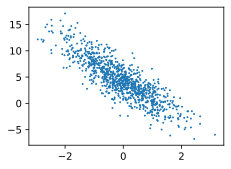

In [5]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1)

 ## 读取数据集

回想一下，训练模型时要对数据集进行遍历，每次抽取一小批量样本，并使用它们来更新我们的模型。
由于这个过程是训练机器学习算法的基础，所以有必要定义一个函数，
该函数能打乱数据集中的样本并以小批量方式获取数据。

在下面的代码中，我们[**定义一个`data_iter`函数，
该函数接收批量大小、特征矩阵和标签向量作为输入，生成大小为`batch_size`的小批量**]。
每个小批量包含一组特征和标签。


In [6]:
def data_iter(batch_size,features,labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

通常，我们利用GPU并行运算的优势，处理合理大小的“小批量”。
每个样本都可以并行地进行模型计算，且每个样本损失函数的梯度也可以被并行计算。
GPU可以在处理几百个样本时，所花费的时间不比处理一个样本时多太多。

我们直观感受一下小批量运算：读取第一个小批量数据样本并打印。
每个批量的特征维度显示批量大小和输入特征数。
同样的，批量的标签形状与`batch_size`相等。


In [7]:
batch_size = 10
for X ,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

tensor([[ 0.0665,  0.2821],
        [-0.2137,  1.1525],
        [-0.0829, -0.1523],
        [-0.9706, -0.3555],
        [ 1.1163, -2.4558],
        [ 0.0521,  0.5230],
        [-0.1997,  0.9608],
        [-0.8743,  1.0938],
        [ 0.3707,  0.5231],
        [ 0.7888,  0.4587]]) 
 tensor([[ 3.3845],
        [-0.1453],
        [ 4.5362],
        [ 3.4692],
        [14.7692],
        [ 2.5296],
        [ 0.5316],
        [-1.2871],
        [ 3.1661],
        [ 4.2279]])


当我们运行迭代时，我们会连续地获得不同的小批量，直至遍历完整个数据集。
上面实现的迭代对教学来说很好，但它的执行效率很低，可能会在实际问题上陷入麻烦。
例如，它要求我们将所有数据加载到内存中，并执行大量的随机内存访问。
在深度学习框架中实现的内置迭代器效率要高得多，
它可以处理存储在文件中的数据和数据流提供的数据。

## 初始化模型参数

[**在我们开始用小批量随机梯度下降优化我们的模型参数之前**]，
(**我们需要先有一些参数**)。
在下面的代码中，我们通过从均值为0、标准差为0.01的正态分布中采样随机数来初始化权重，
并将偏置初始化为0。

In [8]:
w = torch.normal(0,0.01,size=(2,1),requires_grad=True)
b = torch.zeros(1,requires_grad = True)

在初始化参数之后，我们的任务是更新这些参数，直到这些参数足够拟合我们的数据。
每次更新都需要计算损失函数关于模型参数的梯度。
有了这个梯度，我们就可以向减小损失的方向更新每个参数。
因为手动计算梯度很枯燥而且容易出错，所以没有人会手动计算梯度。
我们使用 :numref:`sec_autograd`中引入的自动微分来计算梯度。

## 定义模型

接下来，我们必须[**定义模型，将模型的输入和参数同模型的输出关联起来。**]
回想一下，要计算线性模型的输出，
我们只需计算输入特征$\mathbf{X}$和模型权重$\mathbf{w}$的矩阵-向量乘法后加上偏置$b$。
注意，上面的$\mathbf{Xw}$是一个向量，而$b$是一个标量。
回想一下 :numref:`subsec_broadcasting`中描述的广播机制：
当我们用一个向量加一个标量时，标量会被加到向量的每个分量上。


In [9]:
def linreg(X,w,b):
    return X@w+b

## [**定义损失函数**]

因为需要计算损失函数的梯度，所以我们应该先定义损失函数。
这里我们使用 :numref:`sec_linear_regression`中描述的平方损失函数。
在实现中，我们需要将真实值`y`的形状转换为和预测值`y_hat`的形状相同。


In [10]:
def squared_loss(y_hat,y):
    return (y_hat - y.reshape(y_hat.shape))**2 / 2

## (**定义优化算法**)

正如我们在 :numref:`sec_linear_regression`中讨论的，线性回归有解析解。
尽管线性回归有解析解，但本书中的其他模型却没有。
这里我们介绍小批量随机梯度下降。

在每一步中，使用从数据集中随机抽取的一个小批量，然后根据参数计算损失的梯度。
接下来，朝着减少损失的方向更新我们的参数。
下面的函数实现小批量随机梯度下降更新。
该函数接受模型参数集合、学习速率和批量大小作为输入。每
一步更新的大小由学习速率`lr`决定。
因为我们计算的损失是一个批量样本的总和，所以我们用批量大小（`batch_size`）
来规范化步长，这样步长大小就不会取决于我们对批量大小的选择。


In [14]:
def sgd(params,lr,batch_size):#Stochastic Gradient Descent 随机梯度下降
    with torch.no_grad():
        for param in params:
            param -= lr*param.grad/batch_size
            param.grad.zero_()

## 训练

现在我们已经准备好了模型训练所有需要的要素，可以实现主要的[**训练过程**]部分了。
理解这段代码至关重要，因为从事深度学习后，
相同的训练过程几乎一遍又一遍地出现。
在每次迭代中，我们读取一小批量训练样本，并通过我们的模型来获得一组预测。
计算完损失后，我们开始反向传播，存储每个参数的梯度。
最后，我们调用优化算法`sgd`来更新模型参数。

概括一下，我们将执行以下循环：

* 初始化参数
* 重复以下训练，直到完成
    * 计算梯度$\mathbf{g} \leftarrow \partial_{(\mathbf{w},b)} \frac{1}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} l(\mathbf{x}^{(i)}, y^{(i)}, \mathbf{w}, b)$
    * 更新参数$(\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \eta \mathbf{g}$

在每个*迭代周期*（epoch）中，我们使用`data_iter`函数遍历整个数据集，
并将训练数据集中所有样本都使用一次（假设样本数能够被批量大小整除）。
这里的迭代周期个数`num_epochs`和学习率`lr`都是超参数，分别设为3和0.03。
设置超参数很棘手，需要通过反复试验进行调整。
我们现在忽略这些细节，以后会在 :numref:`chap_optimization`中详细介绍。


In [15]:
lr=0.03
num_epochs=3
net = linreg
loss = squared_loss

In [16]:
for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l = loss(net(X,w,b),y)
        l.sum().backward()
        sgd([w,b],lr,batch_size)
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch {epoch +1},loss {float(train_l.mean()):f}')

epoch 1,loss 0.027798
epoch 2,loss 0.000096
epoch 3,loss 0.000049


In [17]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([ 2.4021e-04, -7.4625e-05], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0005], grad_fn=<RsubBackward1>)


## 本节总结：线性回归的从零实现

这一节完整手写了一遍线性回归训练流程。难点不在某一行代码本身，而在于第一次把多个概念连成闭环：生成数据、随机读取小批量、初始化参数、定义模型、定义损失函数、反向传播、用 SGD 更新参数，最后观察损失下降和参数误差。

### 1. 数据生成

本节先用真实参数 `true_w = [2, -3.4]` 和 `true_b = 4.2` 人工生成数据：

```python
features, labels = synthetic_data(true_w, true_b, 1000)
```

`features` 的形状是 `[1000, 2]`，表示 1000 个样本，每个样本有 2 个特征。`labels` 的形状是 `[1000, 1]`，表示每个样本对应 1 个标签。这里的核心公式是：

```text
y = Xw + b + noise
```

也就是说，数据不是随便来的，而是由一个已知的线性模型加上一点噪声生成的。训练的目标就是反过来从数据中估计出接近 `true_w` 和 `true_b` 的参数。

### 2. 小批量读取数据

`data_iter` 的作用是把整个数据集随机打乱，然后按 `batch_size` 分批返回：

```python
yield features[batch_indices], labels[batch_indices]
```

这里要记住：一个 epoch 内只打乱一次索引，然后按顺序切出每个 batch。因为 `indices` 本身没有重复，所以一个 epoch 内每个样本通常只会被使用一次。下一轮 epoch 会重新调用 `data_iter`，因此会重新打乱顺序。

本节容易错的地方是不要写成：

```python
features[[batch_indices]]
```

正确写法是：

```python
features[batch_indices]
```

因为 `batch_indices` 本身已经是一组索引，不需要再额外包一层方括号。

### 3. epoch 和 batch

`batch` 是每次喂给模型的一小批数据。比如 `batch_size = 10`，就是每次取 10 条样本来计算预测、损失和梯度。

`epoch` 是完整遍历一遍训练集。比如有 1000 条样本，`batch_size = 10`，那么一个 epoch 里面大约有 100 个 batch。`num_epochs = 3` 表示模型完整看 3 遍数据集。

可以这样理解：

```text
batch：每次训练的一小包样本
epoch：把整个数据集完整训练一遍
```

### 4. 模型和损失函数

线性回归模型定义为：

```python
def linreg(X, w, b):
    return X @ w + b
```

`X @ w` 是矩阵乘法，表示每个样本的两个特征和两个权重做线性组合。`b` 是偏置，会通过广播机制加到每个样本的预测值上。

平方损失函数定义为：

```python
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2
```

这里的重难点是 `reshape`：`y.reshape(y_hat.shape)` 是把真实标签 `y` 调整成和预测值 `y_hat` 一样的形状，方便两者相减。`y.shape` 只是查看形状，不是函数，不能写成 `y.shape(...)`。

### 5. 自动求导和 SGD

训练时先计算当前 batch 的损失：

```python
l = loss(net(X, w, b), y)
```

然后反向传播：

```python
l.sum().backward()
```

`l` 是一个 batch 中每个样本的损失，所以先用 `sum()` 合成一个标量，再调用 `backward()` 让 PyTorch 自动计算 `w.grad` 和 `b.grad`。

`sgd` 是 `Stochastic Gradient Descent`，随机梯度下降。这里使用的是小批量随机梯度下降：

```python
param -= lr * param.grad / batch_size
param.grad.zero_()
```

`param -= ...` 是原地更新参数，不能随便改成 `param = param - ...`。后者只是让局部变量 `param` 指向一个新张量，没有真正更新原来的 `w` 和 `b`，还可能导致 `param.grad` 变成 `None`。

`param.grad.zero_()` 的作用是清空梯度。PyTorch 的梯度默认会累加，如果不清零，下一个 batch 的梯度会叠加到上一个 batch 的梯度上，训练结果就会不对。

### 6. 训练循环

最终训练代码的结构是：

```python
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)

    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
```

内层循环负责对每个 batch 做一次预测、计算损失、反向传播和更新参数。外层循环负责重复多个 epoch。每个 epoch 结束后，用整个数据集计算一次平均损失，只用于观察训练效果，因此放在 `torch.no_grad()` 中，不需要记录梯度。

本次运行结果中，loss 从 `0.027798` 降到 `0.000049`，说明模型确实学到了接近真实参数的线性关系。最后打印的参数误差也很小：

```text
w的估计误差: tensor([ 2.4021e-04, -7.4625e-05])
b的估计误差: tensor([0.0005])
```

### 7. 本节最容易混淆的语法点

- 点 `.`：表示访问对象的方法或属性，例如 `labels.detach().numpy()`。
- 括号 `()`：表示调用方法，例如 `numpy()`，少写括号就只是拿到方法本身。
- 逗号 `,`：表示函数参数之间的分隔，例如 `scatter(x, y, 1)`。
- `shape`：查看形状，不是改变形状。
- `reshape(...)`：改变形状。
- `param -= ...`：原地更新参数。
- `param = param - ...`：创建新张量并重新绑定局部变量，不适合这里的参数更新。

### 8. 当前理解

这一节可以看作深度学习训练流程的最小完整版本。虽然模型只是线性回归，但它已经包含了深度学习训练的基本骨架：模型给出预测，损失函数衡量预测错误，自动求导计算梯度，优化器根据梯度更新参数。以后学习更复杂的神经网络时，很多代码表面会换成框架封装，但核心循环仍然是这一套。
